In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

Binary Classification with Random Forest
Accuracy: 0.5278

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.66      0.59       188
           1       0.51      0.38      0.44       172

    accuracy                           0.53       360
   macro avg       0.52      0.52      0.52       360
weighted avg       0.52      0.53      0.52       360

Confusion Matrix:
 [[124  64]
 [106  66]]


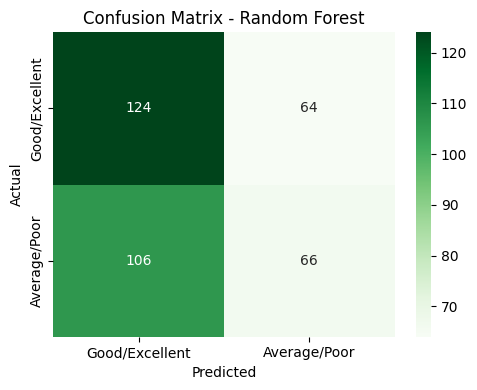

In [ ]:
# Re-implementing the pipeline using RandomForestClassifier for fast and efficient training
from sklearn.ensemble import RandomForestClassifier

# Load and preprocess again
file_path = "/content/drive/MyDrive/CSE422-17 IBU/Lab Assignments/Final AI Project/movie_ratings_dataset.csv"
df = pd.read_csv(file_path)

# Drop missing target
df = df[df['Rating_Category'].notnull()]

# Binary target encoding
# Since we are getting low accuracy
df['Rating_Category'] = df['Rating_Category'].map({
    'Good': 0,
    'Excellent': 0,
    'Average': 1,
    'Poor': 1
})

# Binary feature encoding
df['Has_Famous_Producer'] = df['Has_Famous_Producer'].map({'Yes': 1, 'No': 0})
df['Is_Sequel'] = df['Is_Sequel'].map({'Yes': 1, 'No': 0})

# One-hot encode Genre
df['Genre'] = df['Genre'].fillna('Unknown')
df = pd.get_dummies(df, columns=['Genre'], drop_first=True)

# Feature engineering
df['Budget_x_Actor'] = df['Budget_MillionUSD'] * df['Avg_Actor_Popularity']
df['Marketing_per_min'] = df['Marketing_Spend_MillionUSD'] / (df['Runtime_Minutes'] + 1)

# Drop noisy column
df = df.drop(columns=['Release_Year'])

# Separate X and y
X = df.drop(columns=['Rating_Category'])
y = df['Rating_Category']

# Impute using KNN
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Train/test split and scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Results
print("Binary Classification with Random Forest")
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", report)
print("Confusion Matrix:\n", conf_matrix)

# Plot confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Good/Excellent', 'Average/Poor'],
            yticklabels=['Good/Excellent', 'Average/Poor'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

In [ ]:
# Step 6: Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42)
}

results = {}

# Step 7: Train, evaluate and compare
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} Accuracy: {acc:.4f}")
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    results[name] = acc

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sample


Logistic Regression Accuracy: 0.4778
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       188
           1       0.48      1.00      0.65       172

    accuracy                           0.48       360
   macro avg       0.24      0.50      0.32       360
weighted avg       0.23      0.48      0.31       360

Confusion Matrix:
 [[  0 188]
 [  0 172]]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:18:16] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Random Forest Accuracy: 0.4444
Classification Report:
               precision    recall  f1-score   support

           0       0.41      0.15      0.22       188
           1       0.45      0.76      0.57       172

    accuracy                           0.44       360
   macro avg       0.43      0.46      0.40       360
weighted avg       0.43      0.44      0.39       360

Confusion Matrix:
 [[ 29 159]
 [ 41 131]]

XGBoost Accuracy: 0.4778
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       188
           1       0.48      1.00      0.65       172

    accuracy                           0.48       360
   macro avg       0.24      0.50      0.32       360
weighted avg       0.23      0.48      0.31       360

Confusion Matrix:
 [[  0 188]
 [  0 172]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Neural Network Accuracy: 0.4944
Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.08      0.14       188
           1       0.49      0.95      0.64       172

    accuracy                           0.49       360
   macro avg       0.56      0.51      0.39       360
weighted avg       0.56      0.49      0.38       360

Confusion Matrix:
 [[ 15 173]
 [  9 163]]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


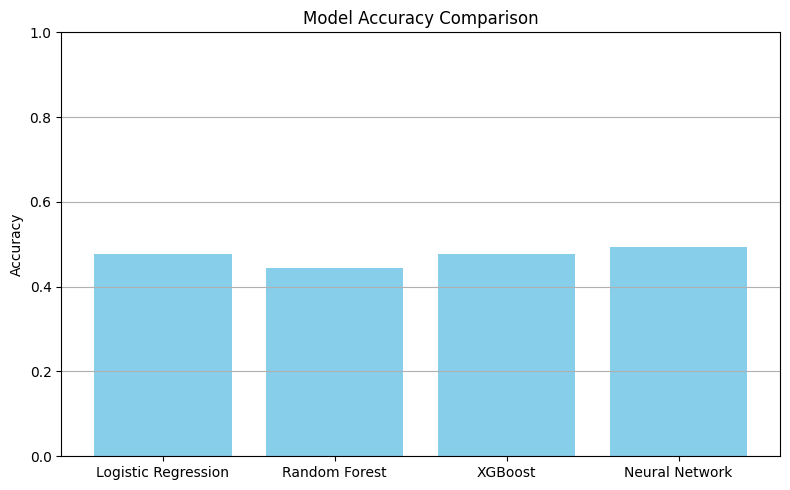

In [ ]:
# Step 8: Plot accuracy comparison
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color='skyblue')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'hidden_layer_sizes': [(128, 100, 50), (100, 50), (64, 32)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'batch_size': [5, 10],
    'max_iter': [5000]
}

# Create MLPClassifier
mlp = MLPClassifier(random_state=42)

# Apply GridSearchCV
grid_search = GridSearchCV(mlp, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

# Best model
best_model = grid_search.best_estimator_

# Predictions
y_pred = best_model.predict(X_test_scaled)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Best Parameters:", grid_search.best_params_)
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", report)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'activation': 'tanh', 'batch_size': 5, 'hidden_layer_sizes': (128, 100, 50), 'max_iter': 5000, 'solver': 'sgd'}
Accuracy: 0.5388888888888889
Confusion Matrix:
 [[103  85]
 [ 81  91]]
Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.55      0.55       188
           1       0.52      0.53      0.52       172

    accuracy                           0.54       360
   macro avg       0.54      0.54      0.54       360
weighted avg       0.54      0.54      0.54       360

